**IMPORTING NECESSARY LIBRARIES**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


**LOAD THE DATASET**

In [14]:
data=pd.read_csv('early_warning_business_failure_with_objects.csv')
data

,company_age,revenue_growth,profit_margin,debt_to_equity,current_ratio,cash_flow,interest_coverage,employee_count,market_volatility,payment_delays,business_failure,industry,company_size,region,ownership_type
0,6.2,25.40,3.80,0.66,2.22,3107383.0,2.32,16.0,0.24,2,0,Retail,Large,East,Public
1,17.5,17.73,-3.97,12.48,NaN,-1279510.0,NaN,171.0,0.29,5,1,Construction,Large,North,Private
2,2.1,10.28,7.08,3.15,1.94,1008326.0,6.73,85.0,0.28,2,0,Construction,Small,West,Private
3,7.4,-0.96,2.53,2.99,1.01,501024.0,2.36,21.0,0.15,1,1,Logistics,Small,East,Partnership
4,20.7,0.12,16.81,2.42,2.43,2315136.0,6.33,NaN,0.45,1,0,Healthcare,Small,South,Private
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,16.3,NaN,2.12,1.57,NaN,-9500.0,1.14,120.0,0.23,3,0,Construction,Small,West,Private
49996,5.5,5.49,1.30,0.88,0.91,114644.0,3.15,160.0,0.28,1,0,Manufacturing,Small,East,Private
49997,1.1,11.51,NaN,2.36,2.54,9486172.0,0.16,41.0,0.19,2,0,Retail,Small,West,Private
49998,1.0,-12.97,NaN,2.22,NaN,-2399941.0,3.59,48.0,0.06,2,1,Construction,Medium,East,Private


**Dependent Variable (Target Variable)**

business_failure

This is the output variable the model aims to predict.

Type: Binary (0 = No Failure, 1 = Failure).

It indicates whether a company experienced business failure.

**Independent Variables (Predictor Variables)**

These are the input features used to predict business failure:

company_age (Numerical),
revenue_growth (Numerical),
profit_margin (Numerical),
debt_to_equity (Numerical),
current_ratio (Numerical),
cash_flow (Numerical),
interest_coverage (Numerical),
employee_count (Numerical),
market_volatility (Numerical),
payment_delays (Numerical),
industry (Categorical),
company_size (Categorical),
region (Categorical),
ownership_type (Categorical).


**PREPROCESSING AND EDA**

In [15]:
data.shape

(50000, 15)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   company_age        50000 non-null  float64
 1   revenue_growth     48050 non-null  float64
 2   profit_margin      41120 non-null  float64
 3   debt_to_equity     50000 non-null  float64
 4   current_ratio      32195 non-null  float64
 5   cash_flow          50000 non-null  float64
 6   interest_coverage  47233 non-null  float64
 7   employee_count     48490 non-null  float64
 8   market_volatility  50000 non-null  float64
 9   payment_delays     50000 non-null  int64  
 10  business_failure   50000 non-null  int64  
 11  industry           48011 non-null  object 
 12  company_size       50000 non-null  object 
 13  region             48544 non-null  object 
 14  ownership_type     48664 non-null  object 
dtypes: float64(9), int64(2), object(4)
memory usage: 5.7+ MB


In [17]:
data.isna().sum()

company_age              0
revenue_growth        1950
profit_margin         8880
debt_to_equity           0
current_ratio        17805
cash_flow                0
interest_coverage     2767
employee_count        1510
market_volatility        0
payment_delays           0
business_failure         0
industry              1989
company_size             0
region                1456
ownership_type        1336
dtype: int64

In [18]:
data.head()

,company_age,revenue_growth,profit_margin,debt_to_equity,current_ratio,cash_flow,interest_coverage,employee_count,market_volatility,payment_delays,business_failure,industry,company_size,region,ownership_type
0,6.2,25.40,3.80,0.66,2.22,3107383.0,2.32,16.0,0.24,2,0,Retail,Large,East,Public
1,17.5,17.73,-3.97,12.48,NaN,-1279510.0,NaN,171.0,0.29,5,1,Construction,Large,North,Private
2,2.1,10.28,7.08,3.15,1.94,1008326.0,6.73,85.0,0.28,2,0,Construction,Small,West,Private
3,7.4,-0.96,2.53,2.99,1.01,501024.0,2.36,21.0,0.15,1,1,Logistics,Small,East,Partnership
4,20.7,0.12,16.81,2.42,2.43,2315136.0,6.33,NaN,0.45,1,0,Healthcare,Small,South,Private


In [19]:
data.tail()

,company_age,revenue_growth,profit_margin,debt_to_equity,current_ratio,cash_flow,interest_coverage,employee_count,market_volatility,payment_delays,business_failure,industry,company_size,region,ownership_type
49995,16.3,NaN,2.12,1.57,NaN,-9500.0,1.14,120.0,0.23,3,0,Construction,Small,West,Private
49996,5.5,5.49,1.30,0.88,0.91,114644.0,3.15,160.0,0.28,1,0,Manufacturing,Small,East,Private
49997,1.1,11.51,NaN,2.36,2.54,9486172.0,0.16,41.0,0.19,2,0,Retail,Small,West,Private
49998,1.0,-12.97,NaN,2.22,NaN,-2399941.0,3.59,48.0,0.06,2,1,Construction,Medium,East,Private
49999,1.1,3.91,NaN,1.38,1.48,3709690.0,5.78,57.0,0.24,2,0,Manufacturing,Small,North,Private


In [20]:
data.columns


Index(['company_age', 'revenue_growth', 'profit_margin', 'debt_to_equity',
       'current_ratio', 'cash_flow', 'interest_coverage', 'employee_count',
       'market_volatility', 'payment_delays', 'business_failure', 'industry',
       'company_size', 'region', 'ownership_type'],
      dtype='object')

In [21]:
data.duplicated().sum()

np.int64(0)

In [22]:
data.describe()

,company_age,revenue_growth,profit_margin,debt_to_equity,current_ratio,cash_flow,interest_coverage,employee_count,market_volatility,payment_delays,business_failure
count,50000.000000,48050.000000,41120.000000,50000.000000,32195.000000,5.000000e+04,47233.000000,48490.000000,50000.000000,50000.000000,50000.000000
mean,9.908658,6.056632,8.005844,2.098496,1.603424,1.592641e+06,3.965485,89.852733,0.250595,2.000320,0.180000
std,9.631626,12.004653,9.974496,1.642982,0.592471,4.329781e+06,3.850371,117.214831,0.098437,1.409823,0.384191
min,0.500000,-40.000000,-31.990000,0.080000,0.200000,-2.681708e+07,0.000000,0.000000,0.050000,0.000000,0.000000
25%,2.900000,-2.010000,1.280000,1.030000,1.200000,-5.152452e+05,1.150000,27.000000,0.180000,1.000000,0.000000
50%,6.900000,6.090000,7.990000,1.640000,1.600000,7.018580e+05,2.770000,55.000000,0.250000,2.000000,0.000000
75%,13.800000,14.170000,14.770000,2.640000,2.010000,3.309342e+06,5.550000,107.000000,0.320000,3.000000,0.000000
max,50.000000,40.000000,35.000000,40.180000,3.870000,3.592869e+07,20.000000,2746.000000,0.600000,11.000000,1.000000


HISTOGRAM

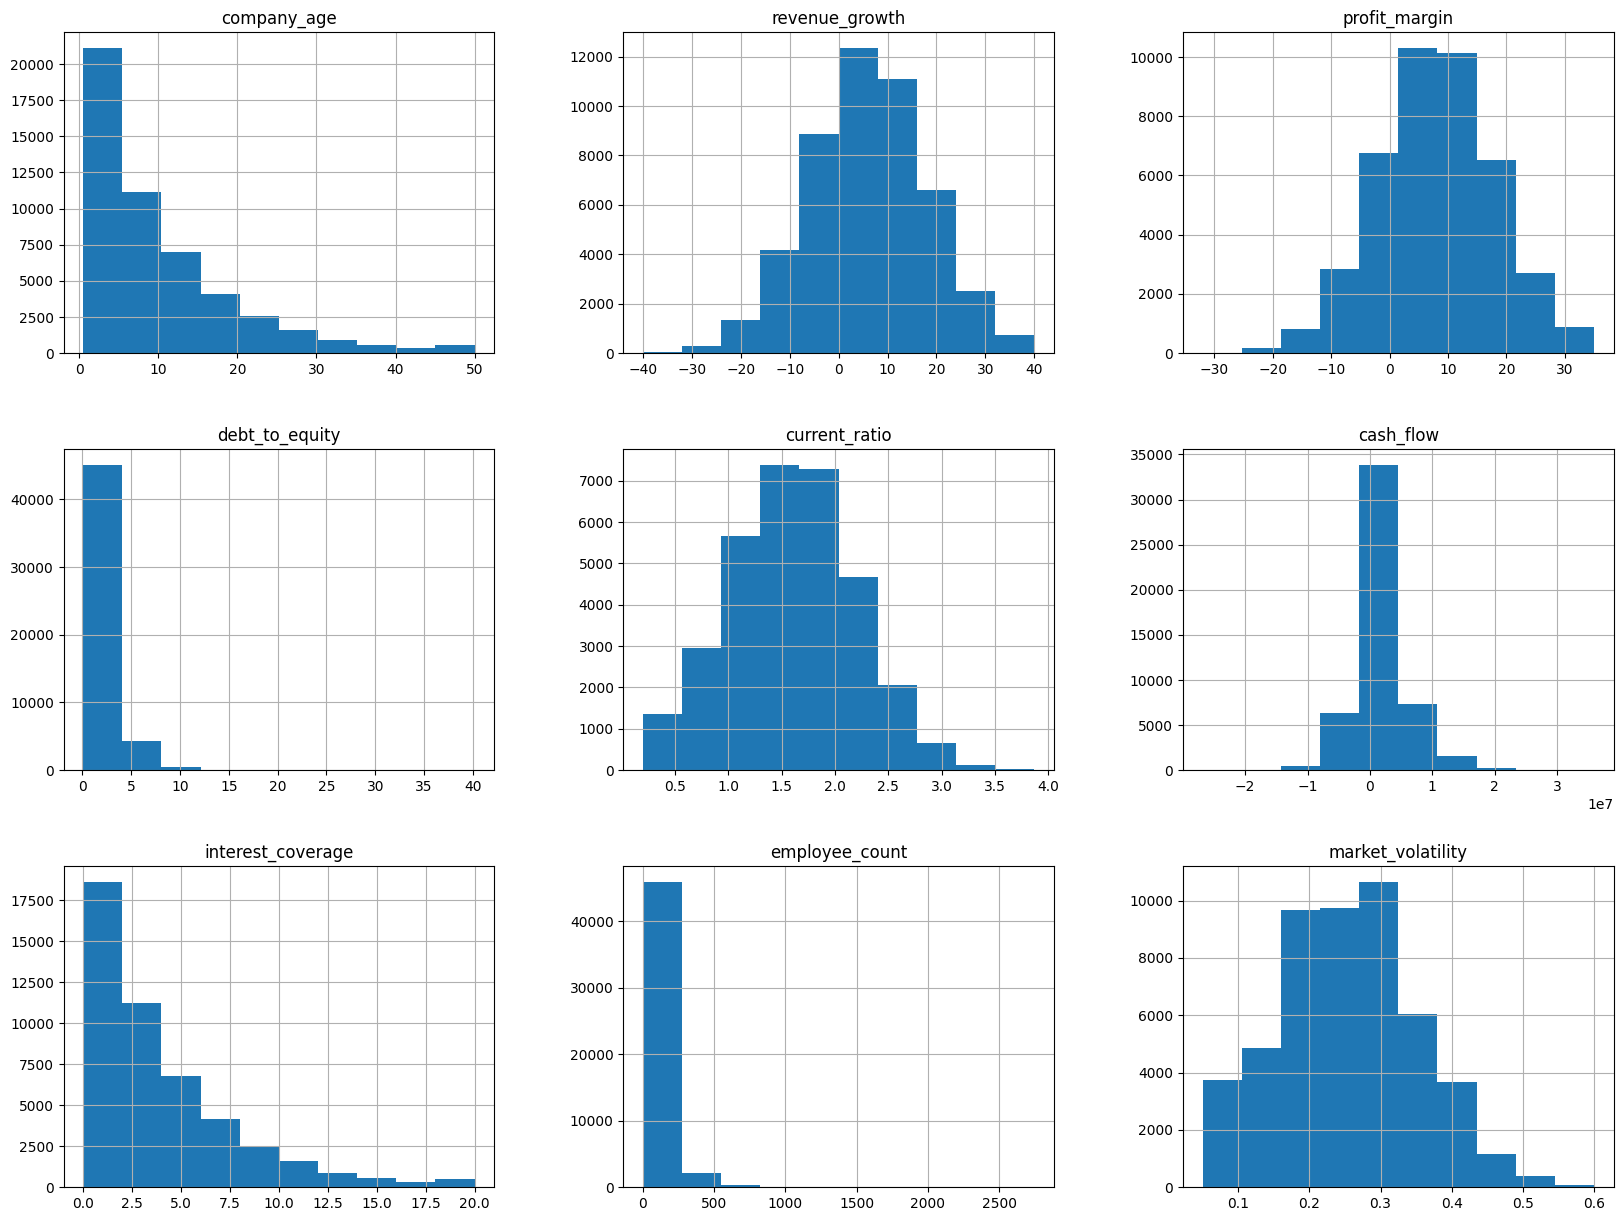

In [23]:
freqgraph=data.select_dtypes(include='float64')
freqgraph.hist(figsize=(20,15));
plt.savefig('plt.png')

FILLING NULL VALUES

In [24]:
data.isnull().sum()

company_age              0
revenue_growth        1950
profit_margin         8880
debt_to_equity           0
current_ratio        17805
cash_flow                0
interest_coverage     2767
employee_count        1510
market_volatility        0
payment_delays           0
business_failure         0
industry              1989
company_size             0
region                1456
ownership_type        1336
dtype: int64

In [25]:
data['revenue_growth']=data['revenue_growth'].fillna(data['revenue_growth'].mean())
data['profit_margin']=data['profit_margin'].fillna(data['profit_margin'].mean())
data['current_ratio']=data['current_ratio'].fillna(data['current_ratio'].mean())
data['interest_coverage']=data['interest_coverage'].fillna(data['interest_coverage'].median())
data['employee_count']=data['employee_count'].fillna(data['employee_count'].median())
data['industry']=data['industry'].fillna(method='bfill')
data['region']=data['region'].fillna(method='bfill')
data['ownership_type']=data['ownership_type'].fillna(method='bfill')
data.isna().sum()


company_age          0
revenue_growth       0
profit_margin        0
debt_to_equity       0
current_ratio        0
cash_flow            0
interest_coverage    0
employee_count       0
market_volatility    0
payment_delays       0
business_failure     0
industry             0
company_size         0
region               0
ownership_type       0
dtype: int64

BOXPLOT

<Axes: >

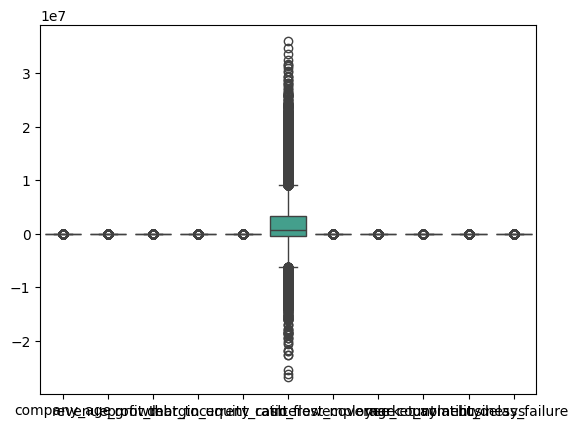

In [26]:
sns.boxplot(data)

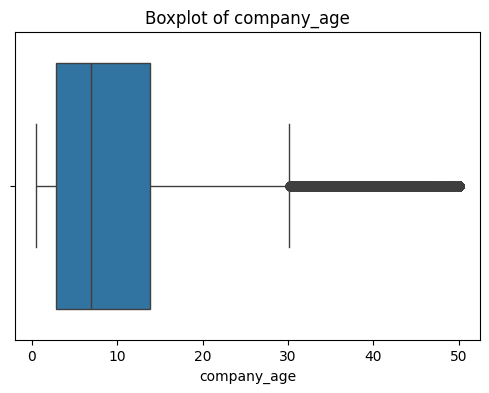

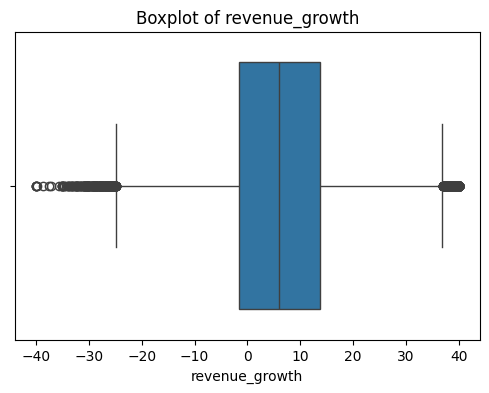

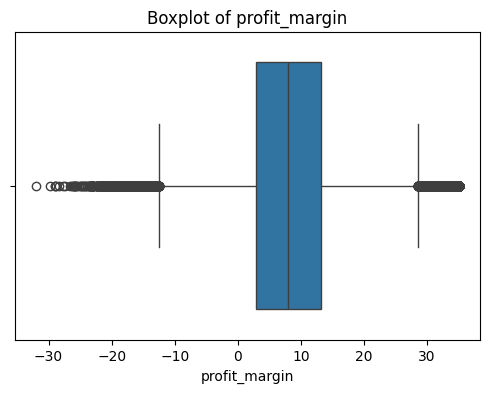

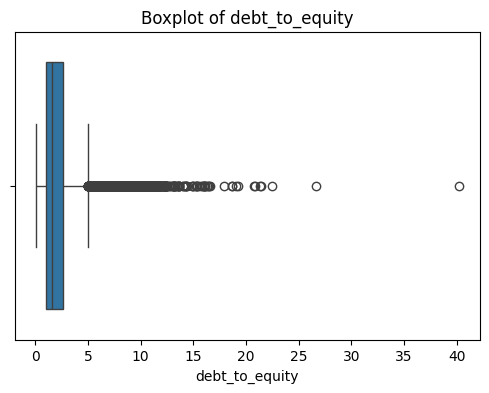

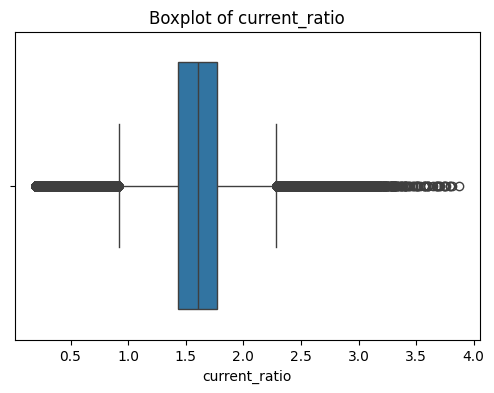

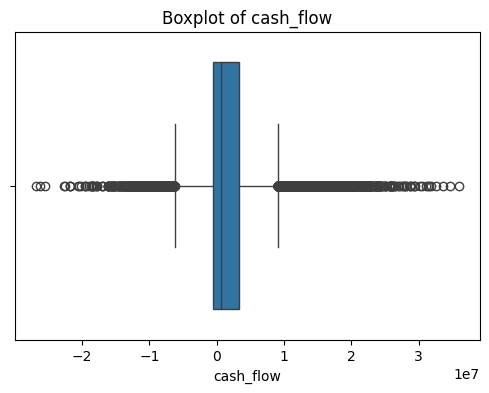

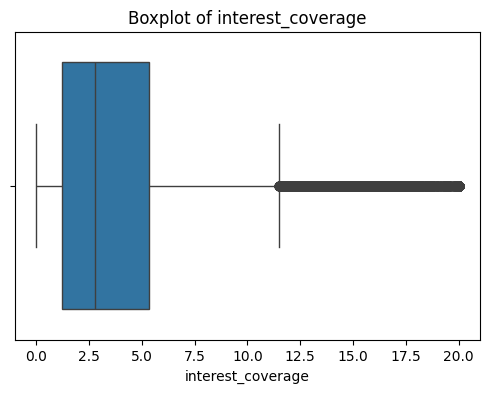

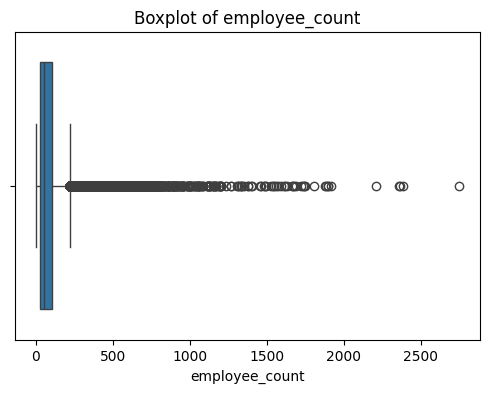

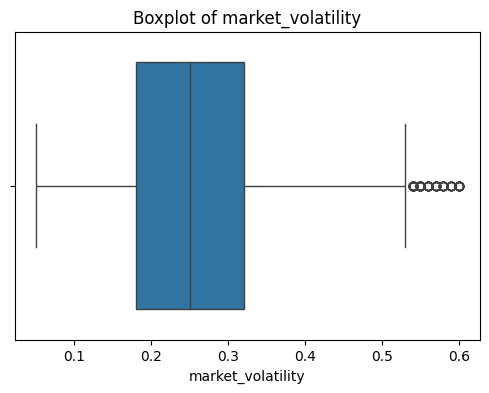

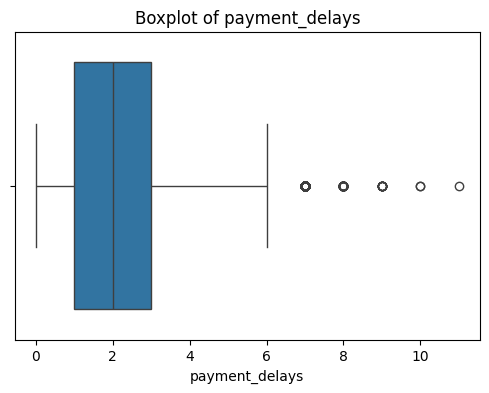

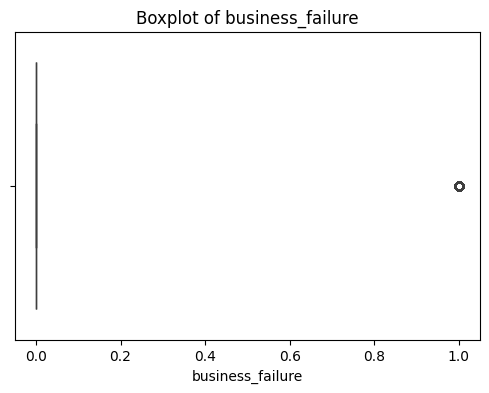

In [27]:



for col in data.select_dtypes(include='number').columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


HANDLING OUTLIERS

In [28]:

numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['company_age', 'revenue_growth', 'profit_margin', 'debt_to_equity',
       'current_ratio', 'cash_flow', 'interest_coverage', 'employee_count',
       'market_volatility', 'payment_delays', 'business_failure'],
      dtype='object')

In [29]:
numeric_cols=numeric_cols.drop('business_failure')
numeric_cols

Index(['company_age', 'revenue_growth', 'profit_margin', 'debt_to_equity',
       'current_ratio', 'cash_flow', 'interest_coverage', 'employee_count',
       'market_volatility', 'payment_delays'],
      dtype='object')

In [30]:
def cap_outliers_iqr(data, columns):
    data_out = data.copy()
    
    for col in columns:
        Q1 = data_out[col].quantile(0.25)
        Q3 = data_out[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        data_out[col] = np.clip(data_out[col], lower, upper)
    
    return data_out

In [31]:
data = cap_outliers_iqr(data, numeric_cols)

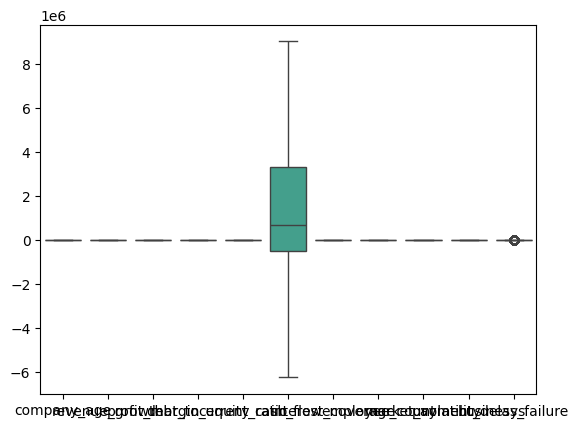

In [32]:
sns.boxplot(data)
plt.savefig('boxplotgraph.png')

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   company_age        50000 non-null  float64
 1   revenue_growth     50000 non-null  float64
 2   profit_margin      50000 non-null  float64
 3   debt_to_equity     50000 non-null  float64
 4   current_ratio      50000 non-null  float64
 5   cash_flow          50000 non-null  float64
 6   interest_coverage  50000 non-null  float64
 7   employee_count     50000 non-null  float64
 8   market_volatility  50000 non-null  float64
 9   payment_delays     50000 non-null  int64  
 10  business_failure   50000 non-null  int64  
 11  industry           50000 non-null  object 
 12  company_size       50000 non-null  object 
 13  region             50000 non-null  object 
 14  ownership_type     50000 non-null  object 
dtypes: float64(9), int64(2), object(4)
memory usage: 5.7+ MB


**ENCODING**

In [34]:
le1=LabelEncoder()
le2=LabelEncoder()
le3=LabelEncoder()
le4=LabelEncoder()

In [35]:
data['industry']=le1.fit_transform(data['industry'])
data['company_size']=le2.fit_transform(data['company_size'])
data['region']=le3.fit_transform(data['region'])
data['ownership_type']=le4.fit_transform(data['ownership_type'])


In [36]:
data.head()

,company_age,revenue_growth,profit_margin,debt_to_equity,current_ratio,cash_flow,interest_coverage,employee_count,market_volatility,payment_delays,business_failure,industry,company_size,region,ownership_type
0,6.2,25.40,3.80,0.660,2.220000,3107383.0,2.32,16.0,0.24,2,0,5,0,0,2
1,17.5,17.73,-3.97,5.055,1.603424,-1279510.0,2.77,171.0,0.29,5,1,0,0,1,1
2,2.1,10.28,7.08,3.150,1.940000,1008326.0,6.73,85.0,0.28,2,0,0,2,3,1
3,7.4,-0.96,2.53,2.990,1.010000,501024.0,2.36,21.0,0.15,1,1,3,2,0,0
4,20.7,0.12,16.81,2.420,2.280000,2315136.0,6.33,55.0,0.45,1,0,1,2,2,1


In [37]:
c=data.corr()
c

,company_age,revenue_growth,profit_margin,debt_to_equity,current_ratio,cash_flow,interest_coverage,employee_count,market_volatility,payment_delays,business_failure,industry,company_size,region,ownership_type
company_age,1.000000,-0.002203,0.001665,0.004441,0.001193,0.001651,0.001334,0.001478,0.008381,0.000772,-0.106815,0.004967,0.006716,-0.005314,0.002349
revenue_growth,-0.002203,1.000000,0.005416,0.003325,0.005322,0.007818,-0.001380,0.005449,0.000144,-0.007641,-0.265294,-0.001442,-0.003348,0.002044,0.001146
profit_margin,0.001665,0.005416,1.000000,0.001295,-0.006491,0.420834,-0.005844,0.000230,0.002435,0.000390,-0.195093,0.001425,-0.008054,0.002435,0.001241
debt_to_equity,0.004441,0.003325,0.001295,1.000000,0.004291,0.002053,-0.037277,-0.003460,0.002818,-0.002805,0.485387,-0.002009,-0.002508,-0.003842,-0.006122
current_ratio,0.001193,0.005322,-0.006491,0.004291,1.000000,-0.000342,0.006760,0.004099,-0.000440,0.004778,-0.065859,-0.001712,0.004779,0.006717,-0.007316
cash_flow,0.001651,0.007818,0.420834,0.002053,-0.000342,1.000000,-0.001533,0.004372,-0.004395,0.002095,-0.205698,-0.010213,0.000665,0.008691,-0.001618
interest_coverage,0.001334,-0.001380,-0.005844,-0.037277,0.006760,-0.001533,1.000000,0.003920,-0.008834,0.001595,-0.206627,-0.002532,-0.003292,0.005782,0.002233
employee_count,0.001478,0.005449,0.000230,-0.003460,0.004099,0.004372,0.003920,1.000000,0.000302,-0.002988,-0.005015,-0.000765,0.000014,0.007030,0.000070
market_volatility,0.008381,0.000144,0.002435,0.002818,-0.000440,-0.004395,-0.008834,0.000302,1.000000,0.002708,0.061524,-0.001628,0.006442,0.006790,-0.002128
payment_delays,0.000772,-0.007641,0.000390,-0.002805,0.004778,0.002095,0.001595,-0.002988,0.002708,1.000000,0.116775,-0.002322,0.001453,-0.005488,0.001434


HEATMAP

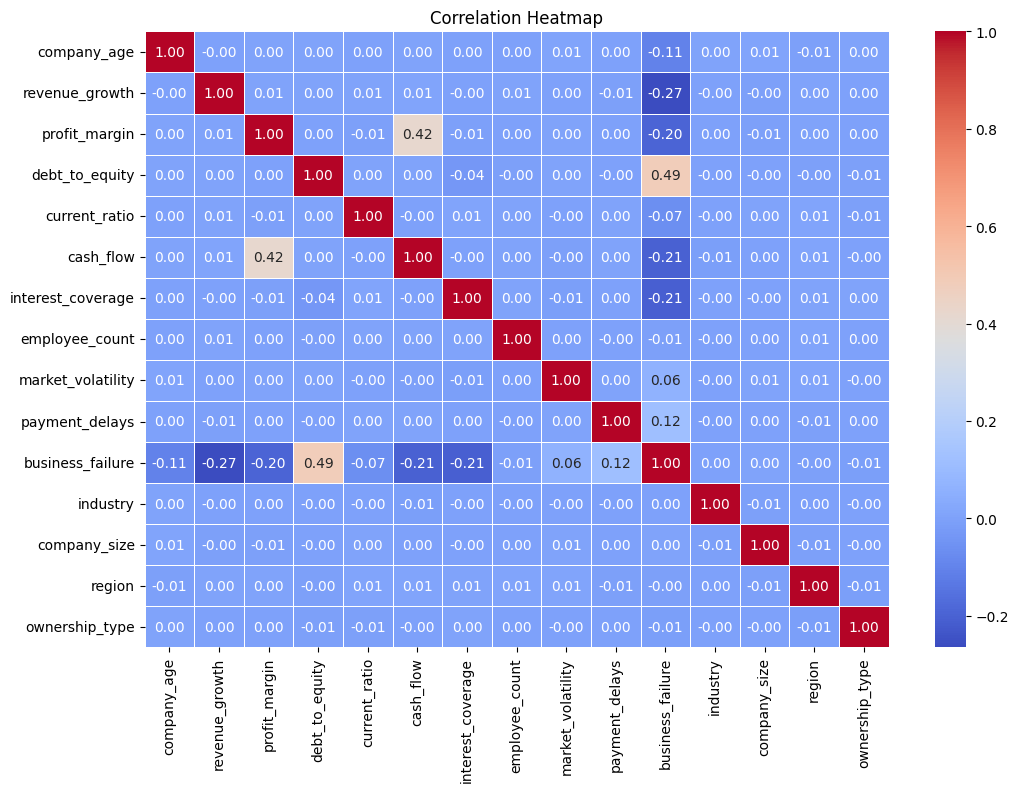

In [38]:
plt.figure(figsize=(12, 8))
sns.heatmap(c,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,cbar=True)
plt.title("Correlation Heatmap")
plt.show()

TARGET DISTRIBUTION

In [110]:
data['business_failure'].value_counts()
#0 = if the business will not fail
#1 = if the business will fail

business_failure
0    41000
1     9000
Name: count, dtype: int64

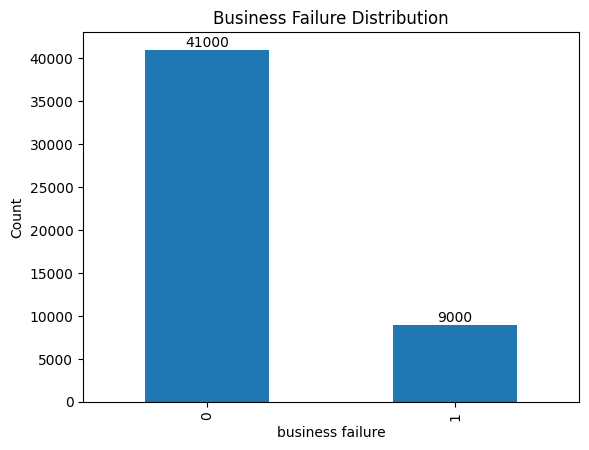

In [112]:
x=data['business_failure'].value_counts().plot(kind='bar')
plt.title("Business Failure Distribution")
plt.xlabel("business failure")
plt.ylabel("Count")
x.bar_label(x.containers[0])
plt.show()

In [39]:
x=data.drop('business_failure',axis=1)
y=data['business_failure']


In [40]:
x

,company_age,revenue_growth,profit_margin,debt_to_equity,current_ratio,cash_flow,interest_coverage,employee_count,market_volatility,payment_delays,industry,company_size,region,ownership_type
0,6.2,25.400000,3.800000,0.660,2.220000,3107383.0,2.32,16.0,0.24,2,5,0,0,2
1,17.5,17.730000,-3.970000,5.055,1.603424,-1279510.0,2.77,171.0,0.29,5,0,0,1,1
2,2.1,10.280000,7.080000,3.150,1.940000,1008326.0,6.73,85.0,0.28,2,0,2,3,1
3,7.4,-0.960000,2.530000,2.990,1.010000,501024.0,2.36,21.0,0.15,1,3,2,0,0
4,20.7,0.120000,16.810000,2.420,2.280000,2315136.0,6.33,55.0,0.45,1,1,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,16.3,6.056632,2.120000,1.570,1.603424,-9500.0,1.14,120.0,0.23,3,0,2,3,1
49996,5.5,5.490000,1.300000,0.880,0.920000,114644.0,3.15,160.0,0.28,1,4,2,0,1
49997,1.1,11.510000,8.005844,2.360,2.280000,9046223.5,0.16,41.0,0.19,2,5,2,3,1
49998,1.0,-12.970000,8.005844,2.220,1.603424,-2399941.0,3.59,48.0,0.06,2,0,1,0,1


In [41]:
y

0        0
1        1
2        0
3        1
4        0
        ..
49995    0
49996    0
49997    0
49998    1
49999    0
Name: business_failure, Length: 50000, dtype: int64

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20,stratify=y)

In [43]:

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

**LOGISTIC REGRESSION**

In [44]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [45]:
lr_y_pred_test=lr.predict(x_test)
lr_y_pred_test

array([0, 0, 1, ..., 0, 0, 0], shape=(10000,))

In [46]:

lr_test_acc = accuracy_score(y_test, lr_y_pred_test)
print("Accuracy Score:", lr_test_acc)

Accuracy Score: 0.9221


In [106]:
lr_pred_train=lr.predict(x_train)
lr_train_acc=accuracy_score(y_train,lr_pred_train)

In [107]:
lr_cm = confusion_matrix(y_test, lr_y_pred_test)
lr_cm

array([[7926,  274],
       [ 505, 1295]])

In [108]:
print("Classification Report:\n")
print(classification_report(y_test, lr_y_pred_test))


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      8200
           1       0.83      0.72      0.77      1800

    accuracy                           0.92     10000
   macro avg       0.88      0.84      0.86     10000
weighted avg       0.92      0.92      0.92     10000



**KNN CLASSIFIER**

In [50]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [51]:
knn_y_pred_test = knn.predict(x_test)
knn_test_acc = accuracy_score(y_test, knn_y_pred_test)
print("Accuracy:", knn_test_acc)

Accuracy: 0.8929


In [52]:
knn_y_pred_train=knn.predict(x_train)
knn_train_acc=accuracy_score(y_train,knn_y_pred_train)
print("Accuracy:", knn_train_acc)

Accuracy: 0.92915


In [53]:
knn_cm = confusion_matrix(y_test, knn_y_pred_test)
knn_cm

array([[7907,  293],
       [ 778, 1022]])

In [54]:
print("Classification Report:\n")
print(classification_report(y_test, knn_y_pred_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.96      0.94      8200
           1       0.78      0.57      0.66      1800

    accuracy                           0.89     10000
   macro avg       0.84      0.77      0.80     10000
weighted avg       0.89      0.89      0.89     10000



**DECISION TREE CLASSIFIER**

In [55]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=5,min_samples_split=10,min_samples_leaf=5)
dt.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10)

In [65]:
dt_pred_test=dt.predict(x_test)
dt_test_acc= accuracy_score(y_test, dt_pred_test)
print("Accuracy:", dt_test_acc)

Accuracy: 0.8844


In [66]:
dt_pred_train = dt.predict(x_train)
dt_train_acc = accuracy_score(y_train,dt_pred_train)
print("Accuracy:", dt_train_acc)

Accuracy: 0.886575


In [67]:
cm = confusion_matrix(y_test, dt_pred_test)
cm

array([[7866,  334],
       [ 822,  978]])

In [68]:
print("Classification Report:\n")
print(classification_report(y_test, dt_pred_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.96      0.93      8200
           1       0.75      0.54      0.63      1800

    accuracy                           0.88     10000
   macro avg       0.83      0.75      0.78     10000
weighted avg       0.88      0.88      0.88     10000



**RANDOM FOREST CLASSIFIER**

In [69]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(n_estimators=200)
rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200)

In [70]:
rf_pred_test = rf.predict(x_test)
rf_test_acc = accuracy_score(y_test,rf_pred_test)
print("Accuracy:", rf_test_acc)

Accuracy: 0.9152


In [71]:
rf_pred_train = rf.predict(x_train)
rf_train_acc = accuracy_score(y_train,rf_pred_train)
print("Accuracy:", rf_train_acc)

Accuracy: 1.0


In [72]:
rf_cm = confusion_matrix(y_test, rf_pred_test)
rf_cm

array([[8004,  196],
       [ 652, 1148]])

In [73]:
print("Classification Report:\n")
print(classification_report(y_test, rf_pred_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      8200
           1       0.85      0.64      0.73      1800

    accuracy                           0.92     10000
   macro avg       0.89      0.81      0.84     10000
weighted avg       0.91      0.92      0.91     10000



**SVC**

In [74]:
from sklearn.svm import SVC

In [75]:
svc_model1=SVC()#rbf (radial basis function)
svc_model1.fit(x_train,y_train)
svc_model1.score(x_test,y_test)

0.921

In [76]:
svc_model2= SVC(kernel="poly",degree=4,C=2.5)
svc_model2.fit(x_train,y_train)
svc_model2.score(x_test,y_test)

0.895

In [77]:
svc_model3=SVC(kernel="sigmoid")
svc_model3.fit(x_train,y_train)
svc_model3.score(x_test,y_test)

0.8945

In [78]:
#best kernal=linear
svc_model4= SVC(kernel='linear')
svc_model4.fit(x_train,y_train)
svc_model4.score(x_test,y_test)

0.9214

In [79]:
svc_pred_test = svc_model4.predict(x_test)
svc_test_acc= accuracy_score(y_test, svc_pred_test)
print("Accuracy:",svc_test_acc)

Accuracy: 0.9214


In [80]:
svc_pred_train = svc_model4.predict(x_train)
svc_train_acc = accuracy_score(y_train,svc_pred_train)
print("Accuracy:", svc_train_acc)

Accuracy: 0.924075


In [81]:
svc_cm = confusion_matrix(y_test, svc_pred_test)
svc_cm

array([[7930,  270],
       [ 516, 1284]])

In [82]:
print("Classification Report:\n")
print(classification_report(y_test,svc_pred_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      8200
           1       0.83      0.71      0.77      1800

    accuracy                           0.92     10000
   macro avg       0.88      0.84      0.86     10000
weighted avg       0.92      0.92      0.92     10000



**NAIVE BAYES**

In [83]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train, y_train)

GaussianNB()

In [84]:
nb_pred_test=nb.predict(x_test)
nb_test_acc = accuracy_score(y_test,nb_pred_test)
print("Accuracy:",nb_test_acc)

Accuracy: 0.9086


In [85]:
nb_pred_train = nb.predict(x_train)
nb_train_acc = accuracy_score(y_train,nb_pred_train)
print("Accuracy:", nb_train_acc)

Accuracy: 0.90995


In [86]:
nb_cm = confusion_matrix(y_test, nb_pred_test)
nb_cm

array([[7911,  289],
       [ 625, 1175]])

In [87]:
print("Classification Report nb:\n")
print(classification_report(y_test, nb_pred_test))

Classification Report nb:

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      8200
           1       0.80      0.65      0.72      1800

    accuracy                           0.91     10000
   macro avg       0.86      0.81      0.83     10000
weighted avg       0.90      0.91      0.90     10000



**GRADIENT BOOST**

In [88]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(x_train,y_train)

GradientBoostingClassifier()

In [89]:
gb_pred_test=gb.predict(x_test)
gb_test_acc = accuracy_score(y_test,gb_pred_test)
print("Accuracy:",gb_test_acc)

Accuracy: 0.916


In [90]:
gb_pred_train = gb.predict(x_train)
gb_train_acc = accuracy_score(y_train,gb_pred_train)
print("Accuracy:", gb_train_acc)

Accuracy: 0.924775


In [91]:
gb_cm = confusion_matrix(y_test, gb_pred_test)
gb_cm

array([[7999,  201],
       [ 639, 1161]])

In [92]:
print("Classification Report:\n")
print(classification_report(y_test,gb_pred_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      8200
           1       0.85      0.65      0.73      1800

    accuracy                           0.92     10000
   macro avg       0.89      0.81      0.84     10000
weighted avg       0.91      0.92      0.91     10000



**XG BOOST**

In [93]:
!pip install xgboost

In [94]:
from xgboost import XGBClassifier
xgb= XGBClassifier()
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [95]:
xgb_pred_test=xgb.predict(x_test)
xgb_test_acc = accuracy_score(y_test,xgb_pred_test)
print("Accuracy:",gb_test_acc)

Accuracy: 0.916


In [96]:
xgb_pred_train = xgb.predict(x_train)
xgb_train_acc = accuracy_score(y_train,xgb_pred_train)
print("Accuracy:", xgb_train_acc)

Accuracy: 0.97205


In [97]:
xgb_cm = confusion_matrix(y_test, xgb_pred_test)
xgb_cm

array([[7853,  347],
       [ 490, 1310]])

In [98]:
print("Classification Report:\n")
print(classification_report(y_test, xgb_pred_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8200
           1       0.79      0.73      0.76      1800

    accuracy                           0.92     10000
   macro avg       0.87      0.84      0.85     10000
weighted avg       0.91      0.92      0.91     10000



**ADABOOST**

In [99]:
from sklearn.ensemble import AdaBoostClassifier
adb= AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=200)
adb.fit(x_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=200)

In [100]:
adb_pred_test=adb.predict(x_test)
adb_test_acc = accuracy_score(y_test,adb_pred_test)
print("Accuracy:",adb_test_acc)

Accuracy: 0.9171


In [101]:
adb_pred_train = adb.predict(x_train)
adb_train_acc = accuracy_score(y_train,adb_pred_train)
print("Accuracy:", adb_train_acc)

Accuracy: 0.922225


In [102]:
adb_cm = confusion_matrix(y_test, adb_pred_test)
adb_cm

array([[7936,  264],
       [ 565, 1235]])

In [103]:
print("Classification Report:\n")
print(classification_report(y_test,adb_pred_test))

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      8200
           1       0.82      0.69      0.75      1800

    accuracy                           0.92     10000
   macro avg       0.88      0.83      0.85     10000
weighted avg       0.91      0.92      0.91     10000



INITIAL PERFORMANCE

In [109]:
tb=pd. DataFrame()
tb["model "]=pd. Series(["LG","KNN","DT","RF","SVC","NB","GB","XGB","ADB"])
tb["Test Accuracy "]=pd. Series([lr_test_acc*100,knn_test_acc*100,dt_test_acc*100,rf_test_acc*100,svc_test_acc*100,nb_test_acc*100,gb_test_acc*100,xgb_test_acc*100,adb_test_acc*100])
tb["Train Accuracy "]=pd. Series([lr_train_acc*100,knn_train_acc*100,dt_train_acc*100,rf_train_acc*100,svc_train_acc*100,nb_train_acc*100,gb_train_acc*100,xgb_train_acc*100,adb_train_acc*100])
tb

,model,Test Accuracy,Train Accuracy
0,LG,92.21,92.3875
1,KNN,89.29,92.9150
2,DT,88.44,88.6575
3,RF,91.52,100.0000
4,SVC,92.14,92.4075
5,NB,90.86,90.9950
6,GB,91.60,92.4775
7,XGB,91.63,97.2050
8,ADB,91.71,92.2225


**BALANCING**

In [19]:
data["business_failure"].value_counts()

business_failure
0    41000
1     9000
Name: count, dtype: int64

In [20]:
from imblearn.over_sampling import SMOTE
over=SMOTE(random_state=2)
x_os,y_os=over.fit_resample(x,y)

In [21]:
y_os.value_counts()

business_failure
0    41000
1    41000
Name: count, dtype: int64

In [22]:

sc=StandardScaler()
x_os=sc.fit_transform(x_os)

In [23]:

x_train_os,x_test_os,y_train_os,y_test_os=train_test_split(x_os,y_os,test_size=0.3,random_state=42)

****HYPERPARAMETER TUNING****

**LOGISTIC REGRESSION**

In [25]:
from sklearn.model_selection import GridSearchCV

In [90]:
from sklearn.linear_model import LogisticRegression #best model
LR=LogisticRegression()
param={'penalty':['l1','l2'],'C':[0.01,0.1,1,10,100],'solver':['liblinear','saga','ibfgs'],'max_iter':[100,500,1000]}
lr2=GridSearchCV(LR,param,cv=10,scoring='accuracy',n_jobs=-1)
lr2.fit(x_train_os,y_train_os)
print(lr2.best_params_)
print(lr2.best_score_)

{'C': 0.01, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
0.9133972125435541


In [28]:
lr_new=LogisticRegression(C=0.01,max_iter=1000,penalty='l1',solver='saga')
lr_new.fit(x_train_os,y_train_os)

LogisticRegression(C=0.01, max_iter=1000, penalty='l1', solver='saga')

In [54]:
print('Test Acccuracy:',lr_new.score(x_test_os,y_test_os))
print('Train Accuracy:',lr_new.score(x_train_os,y_train_os))

y_pred_test_os=lr_new.predict(x_test_os)
y_pred_train_os=lr_new.predict(x_train_os)

lr_test_acc=accuracy_score(y_test_os,y_pred_test_os)*100
lr_train_acc=accuracy_score(y_train_os,y_pred_train_os)*100

print('accuracy score of test:',lract)
print('accuracy score of train:',lracn)



Test Acccuracy: 0.9145121951219513
Train Accuracy: 0.9133275261324042
accuracy score of test: 91.45121951219512
accuracy score of train: 91.33275261324042


**KNN**

In [39]:
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier()
param2={'n_neighbors':[3,5,11,27,59],'weights':['uniform','distance']}
knn2=GridSearchCV(KNN,param2,cv=5,scoring='accuracy',n_jobs=-1)
knn2.fit(x_train_os,y_train_os)
print(knn2.best_params_)
print(knn2.best_score_)

{'n_neighbors': 11, 'weights': 'distance'}
0.899808362369338


In [31]:
 knn_new=KNeighborsClassifier(n_neighbors=11,weights='distance')
knn_new.fit(x_train_os,y_train_os)

KNeighborsClassifier(n_neighbors=11, weights='distance')

In [32]:
print('Test Acccuracy:',knn_new.score(x_test_os,y_test_os))
print('Train Accuracy:',knn_new.score(x_train_os,y_train_os))

y_pred_test_os2=knn_new.predict(x_test_os)
y_pred_train_os2=knn_new.predict(x_train_os)

Knn_test_acc=accuracy_score(y_test_os,y_pred_test_os2)*100
Knn_train_acc=accuracy_score(y_train_os,y_pred_train_os2)*100

print('accuracy score of test:',Knn_test_acc)
print('accuracy score of train:',Knn_train_acc)

Test Acccuracy: 0.9059756097560976
Train Accuracy: 1.0
accuracy score of test: 90.59756097560975
accuracy score of train: 100.0


DECISION TREE CLASSIFIER

In [93]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier()
param3={'criterion': ['gini', 'entropy'],'max_depth': [5, 10, 20, 30],'min_samples_split': [2, 5, 10]}
dt2=GridSearchCV(DT,param3,cv=10,scoring='accuracy',n_jobs=-1)
dt2.fit(x_train_os,y_train_os)
print(dt2.best_params_)
print(dt2.best_score_)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5}
0.8830836236933799


In [34]:
dt_new=DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_split=5)
dt_new.fit(x_train_os,y_train_os)

DecisionTreeClassifier(max_depth=10, min_samples_split=5)

In [35]:
print('Test Acccuracy:',dt_new.score(x_test_os,y_test_os))
print('Train Accuracy:',dt_new.score(x_train_os,y_train_os))

y_pred_test_os3=dt_new.predict(x_test_os)
y_pred_train_os3=dt_new.predict(x_train_os)

dt_test_acc=accuracy_score(y_test_os,y_pred_test_os3)*100
dt_train_acc=accuracy_score(y_train_os,y_pred_train_os3)*100

print('accuracy score of test:',dt_test_acc)
print('accuracy score of train:',dt_train_acc)

Test Acccuracy: 0.8889837398373984
Train Accuracy: 0.9157665505226481
accuracy score of test: 88.89837398373984
accuracy score of train: 91.57665505226481


**RANDOM FOREST**

In [35]:
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier()
param4={ 'n_estimators': [ 200, 300],'max_depth': [None,20],'criterion': ['gini', 'entropy']}
rf2=GridSearchCV(RF,param4,cv=5,scoring='accuracy',n_jobs=-1)
rf2.fit(x_train_os,y_train_os)
print(rf2.best_params_)
print(rf2.best_score_)

{'criterion': 'gini', 'max_depth': None, 'n_estimators': 300}
0.9305400696864112


In [36]:
rf_new=RandomForestClassifier(criterion='gini',max_depth=None,n_estimators=300)
rf_new.fit(x_train_os,y_train_os)

RandomForestClassifier(n_estimators=300)

In [37]:
print('Test Acccuracy:',rf_new.score(x_test_os,y_test_os))
print('Train Accuracy:',rf_new.score(x_train_os,y_train_os))

y_pred_test_os4=rf_new.predict(x_test_os)
y_pred_train_os4=rf_new.predict(x_train_os)

rf_test_acc=accuracy_score(y_test_os,y_pred_test_os4)*100
rf_train_acc=accuracy_score(y_train_os,y_pred_train_os4)*100

print('accuracy score of test:',rf_test_acc)
print('accuracy score of train:',rf_train_acc)

Test Acccuracy: 0.9343089430894309
Train Accuracy: 1.0
accuracy score of test: 93.4308943089431
accuracy score of train: 100.0


**SVC**

In [37]:
from sklearn.svm import SVC
svcc=SVC()
param5={'C': [0.1, 1, 10],'kernel': ['linear', 'poly'],'gamma': ['scale', 'auto']}
svc2=GridSearchCV(svcc,param5,cv=3,scoring='accuracy',n_jobs=-1)
svc2.fit(x_train_os,y_train_os)
print(svc2.best_params_)
print(svc2.best_score_)

{'C': 1, 'gamma': 'scale', 'kernel': 'poly'}
0.9137804589193808


In [40]:
svc_new=SVC(C=1,kernel='poly',gamma='auto')
svc_new.fit(x_train_os,y_train_os)

SVC(C=1, gamma='auto', kernel='poly')

In [41]:
print('Test Acccuracy:',svc_new.score(x_test_os,y_test_os))
print('Train Accuracy:',svc_new.score(x_train_os,y_train_os))

y_pred_test_os5=svc_new.predict(x_test_os)
y_pred_train_os5=svc_new.predict(x_train_os)

svc_test_acc=accuracy_score(y_test_os,y_pred_test_os5)*100
svc_train_acc=accuracy_score(y_train_os,y_pred_train_os5)*100

print('accuracy score of test:',svc_test_acc)
print('accuracy score of train:',svc_train_acc)

Test Acccuracy: 0.9154878048780488
Train Accuracy: 0.9189372822299652
accuracy score of test: 91.54878048780488
accuracy score of train: 91.89372822299651


**naive bayes**

In [99]:
from sklearn.naive_bayes import GaussianNB
NB=GaussianNB()
param6={ 'var_smoothing': [1e-9, 1e-8, 1e-7]}
nb2=GridSearchCV(NB,param6,cv=10,scoring='accuracy',n_jobs=-1)
nb2.fit(x_train_os,y_train_os)
print(nb2.best_params_)
print(nb2.best_score_)

{'var_smoothing': 1e-09}
0.8802961672473867


In [42]:
nb_new=GaussianNB(var_smoothing=1e-9)
nb_new.fit(x_train_os,y_train_os)

GaussianNB()

In [43]:
print('Test Acccuracy:',nb_new.score(x_test_os,y_test_os))
print('Train Accuracy:',nb_new.score(x_train_os,y_train_os))

y_pred_test_os6=nb_new.predict(x_test_os)
y_pred_train_os6=nb_new.predict(x_train_os)

nb_test_acc=accuracy_score(y_test_os,y_pred_test_os6)*100
nb_train_acc=accuracy_score(y_train_os,y_pred_train_os6)*100

print('accuracy score of test:',nb_test_acc)
print('accuracy score of train:',nb_train_acc)

Test Acccuracy: 0.8822357723577235
Train Accuracy: 0.8801219512195122
accuracy score of test: 88.22357723577235
accuracy score of train: 88.01219512195122


**GRADIENT BOOSTING**

In [108]:
from sklearn.ensemble import GradientBoostingClassifier
GB=GradientBoostingClassifier()
param7={ 'n_estimators': [50, 100],'learning_rate': [0.01, 0.1],'max_depth': [3, 5]}
gb2=GridSearchCV(GB,param7,cv=10,scoring='accuracy',n_jobs=-1)
gb2.fit(x_train_os,y_train_os)
print(gb2.best_params_)
print(gb2.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
0.9267073170731708


In [44]:
gb_new=GradientBoostingClassifier(learning_rate=0.1,max_depth=5,n_estimators=100)
gb_new.fit(x_train_os,y_train_os)

GradientBoostingClassifier(max_depth=5)

In [45]:
print('Test Acccuracy:',gb_new.score(x_test_os,y_test_os))
print('Train Accuracy:',gb_new.score(x_train_os,y_train_os))

y_pred_test_os7=gb_new.predict(x_test_os)
y_pred_train_os7=gb_new.predict(x_train_os)

gb_test_acc=accuracy_score(y_test_os,y_pred_test_os7)*100
gb_train_acc=accuracy_score(y_train_os,y_pred_train_os7)*100

print('accuracy score of test:',gb_test_acc)
print('accuracy score of train:',gb_train_acc)

Test Acccuracy: 0.9276016260162602
Train Accuracy: 0.9406445993031359
accuracy score of test: 92.76016260162602
accuracy score of train: 94.06445993031359


**XGBOOST**

In [102]:
from xgboost import XGBClassifier
XGB=XGBClassifier()
param8={'n_estimators': [50, 100],'max_depth': [3, 5],'learning_rate': [0.01, 0.1]}
xgb2=GridSearchCV(XGB,param8,cv=10,scoring='accuracy',n_jobs=-1)
xgb2.fit(x_train_os,y_train_os)
print(xgb2.best_params_)
print(xgb2.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
0.9258188153310105


In [46]:
xgb_new=XGBClassifier(learning_rate=0.1,max_depth=5,n_estimators=100)
xgb_new.fit(x_train_os,y_train_os)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [47]:
print('Test Acccuracy:',xgb_new.score(x_test_os,y_test_os))
print('Train Accuracy:',xgb_new.score(x_train_os,y_train_os))

y_pred_test_os8=xgb_new.predict(x_test_os)
y_pred_train_os8=xgb_new.predict(x_train_os)

xgb_test_acc=accuracy_score(y_test_os,y_pred_test_os8)*100
xgb_train_acc=accuracy_score(y_train_os,y_pred_train_os8)*100

print('accuracy score of test:',xgb_test_acc)
print('accuracy score of train:',xgb_train_acc)

Test Acccuracy: 0.9265040650406504
Train Accuracy: 0.9395993031358885
accuracy score of test: 92.65040650406505
accuracy score of train: 93.95993031358884


**ADABOOST**

In [105]:
from sklearn.ensemble import AdaBoostClassifier
AB=AdaBoostClassifier()
param9={'n_estimators': [50, 100],'learning_rate': [0.01, 0.1, 1]}
ab2=GridSearchCV(AB,param9,cv=10,scoring='accuracy',n_jobs=-1)
ab2.fit(x_train_os,y_train_os)
print(ab2.best_params_)
print(ab2.best_score_)

{'learning_rate': 1, 'n_estimators': 100}
0.9029268292682925


In [48]:
ab_new=XGBClassifier(learning_rate=1,n_estimators=100)
ab_new.fit(x_train_os,y_train_os)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [49]:
print('Test Acccuracy:',ab_new.score(x_test_os,y_test_os))
print('Train Accuracy:',ab_new.score(x_train_os,y_train_os))

y_pred_test_os9=ab_new.predict(x_test_os)
y_pred_train_os9=ab_new.predict(x_train_os)

ab_test_acc=accuracy_score(y_test_os,y_pred_test_os9)*100
ab_train_acc=accuracy_score(y_train_os,y_pred_train_os9)*100

print('accuracy score of test:',ab_test_acc)
print('accuracy score of train:',ab_train_acc)

Test Acccuracy: 0.9320731707317074
Train Accuracy: 0.9973693379790941
accuracy score of test: 93.20731707317074
accuracy score of train: 99.73693379790942


TRAIN AND TEST ACCURACY

In [56]:
tb1=pd.DataFrame()
tb1["model "]=pd.Series(["LR","KNN","DT","RF","SVC","NB","GB","XGB","ADB"])
tb1["Test Accuracy "]=pd.Series([lr_test_acc,Knn_test_acc,dt_test_acc,rf_test_acc,svc_test_acc,nb_test_acc,gb_test_acc,xgb_test_acc,ab_test_acc])
tb1["Train Accuracy "]=pd.Series([lr_train_acc,Knn_train_acc,dt_train_acc,rf_train_acc,svc_train_acc,nb_train_acc,gb_train_acc,xgb_train_acc,ab_train_acc])
tb1

,model,Test Accuracy,Train Accuracy
0,LR,91.451220,91.332753
1,KNN,90.597561,100.000000
2,DT,88.898374,91.576655
3,RF,93.430894,100.000000
4,SVC,91.548780,91.893728
5,NB,88.223577,88.012195
6,GB,92.760163,94.064460
7,XGB,92.650407,93.959930
8,ADB,93.207317,99.736934


*CONFUSION MATRIX*

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [58]:
y_pred =lr_new.predict(x_test_os)

In [59]:
cm = confusion_matrix(y_test_os,y_pred)
print(cm)

[[11078  1223]
 [  880 11419]]


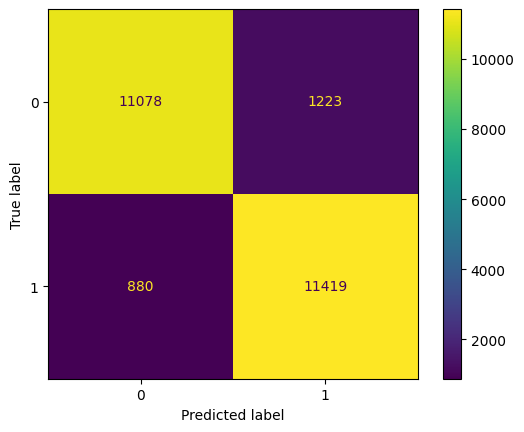

In [60]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [62]:
import joblib
joblib.dump(lr_new,'C:/Users/vpvai/early_warning_business_failure_with_objects.pkl')

['C:/Users/vpvai/early_warning_business_failure_with_objects.pkl']

In [63]:
joblib.dump(le1,'C:/Users/vpvai/le1.pkl')
joblib.dump(le2,'C:/Users/vpvai/le2.pkl')
joblib.dump(le3,'C:/Users/vpvai/le3.pkl')
joblib.dump(le4,'C:/Users/vpvai/le4.pkl')
joblib.dump(sc,'C:/Users/vpvai/sc.pkl')


['C:/Users/vpvai/sc.pkl']